# EDA

This file is cleaning the data befoe exploring the time series. it follows the following steps:
- Step 1: Checking for Missing Data
- Step 2: Handling Outliers
- Step 3: Fill missing dates with zero sales
- Step 4: Feature Engineering: turning a date into useful signals
- Step 5: Visualizing Time-Series Data
- Step 6: Examining the Impact of Holidays
- Step 7: Analyzing Perishable Items


**Additional Notes**

>Wages in the public sector are paid every two weeks on the **15** th and on the **last day of the month**. Supermarket sales could be affected by this.

>A magnitude 7.8 **earthquake** struck Ecuador on **April 16, 2016**. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

## Libraries

Installing the needed libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Checking for Missing Data, Handlining Outliers and Filling missing values

Loading and checking for missing data in each file
- holiday.csv
- oil.csv
- stores.csv
- timeseries.csv


In [65]:
# define path
path = "../data/raw/"

### stores.csv

In [66]:
# stores data
stores_df = pd.read_csv(path + "stores.csv")
print('Stores DataFrame:')
print(stores_df.shape)
print(f"Na values in stores_df: \n{stores_df.isna().sum()}")
print(f"Statistics of stores_df: \n{stores_df.describe()}")

Stores DataFrame:
(54, 3)
Na values in stores_df: 
store_nbr    0
city         0
region       0
dtype: int64
Statistics of stores_df: 
       store_nbr
count  54.000000
mean   27.500000
std    15.732133
min     1.000000
25%    14.250000
50%    27.500000
75%    40.750000
max    54.000000


**Importend:** Need to use this to find the right holidays. **store_nbr 44**

In [67]:
# print store_nbr 44 information
print(f"Information for store_nbr 44: \n{stores_df[stores_df['store_nbr'] == 44]}")
city = stores_df[stores_df['store_nbr'] == 44]['city'].values[0]
region = stores_df[stores_df['store_nbr'] == 44]['region'].values[0]

Information for store_nbr 44: 
    store_nbr   city     region
43         44  Quito  Pichincha


### holidays.csv

In [68]:
# holiday data
holiday_df = pd.read_csv(path + "holidays.csv")
print('Holiday DataFrame:')
print(holiday_df.shape)
print(f"Na values in holiday_df: \n{holiday_df.isna().sum()}")
print(f"Statistics of holiday_df: \n{holiday_df.describe()}")

Holiday DataFrame:
(350, 4)
Na values in holiday_df: 
date           0
locale         0
locale_name    0
description    0
dtype: int64
Statistics of holiday_df: 
              date    locale locale_name description
count          350       350         350         350
unique         312         3          24         103
top     2014-06-25  National     Ecuador    Carnaval
freq             4       174         174          10


> Filter the hoildays to only have all national holidays + all regional holidays from Pichincha + all local hoildays from Quito

In [69]:
# holiday subset
holidays_store_44_df = holiday_df[(holiday_df['locale_name'] == city) | (holiday_df['locale_name'] == region) | (holiday_df['locale'] == 'National')]
print(f"Holiday data for store_nbr 44: \n{holidays_store_44_df.shape}")

Holiday data for store_nbr 44: 
(187, 4)


### oil.csv

In [70]:
# oil data
oil_df = pd.read_csv(path + "oil.csv")
print('Oil DataFrame:')
print(oil_df.shape)
print(f"Na values in oil_df: \n{oil_df.isna().sum()}")
print(f"Statistics of oil_df: \n{oil_df.describe()}")

Oil DataFrame:
(1218, 2)
Na values in oil_df: 
date           0
dcoilwtico    43
dtype: int64
Statistics of oil_df: 
        dcoilwtico
count  1175.000000
mean     67.714366
std      25.630476
min      26.190000
25%      46.405000
50%      53.190000
75%      95.660000
max     110.620000


> Fill the NaN with value before ffill() and the first value with the value after bfill()

**Important:** make sure time series is sorted correctly.

In [71]:
# sort by date
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df = oil_df.sort_values('date')

# set date as index
oil_df.set_index('date', inplace=True)

# ffill missing values
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill()
# bfill missing values to get the first value in the dataset
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].bfill()

# check for remaining missing values
print(f"Na values in oil_df after filling: \n{oil_df.isna().sum()}")

Na values in oil_df after filling: 
dcoilwtico    0
dtype: int64


> Check if date values are missing

In [72]:
# create a complete date range from the minimum to maximum date in the oil_df
dates = pd.date_range(start=oil_df.index.min(), end=oil_df.index.max(), freq='D')
# print difference between the complete date range and the existing dates in oil_df
print(f"Missing dates in oil_df: \n{dates.difference(oil_df.index)}")

# reindex oil_df to the complete date range, filling missing dates with NaN
oil_df = oil_df.reindex(dates)
# ffill missing values again to fill the newly introduced NaN values for missing dates
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill()
# bfill missing values to get the first value in the dataset if the first date was missing
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].bfill()

# check for remaining missing values after reindexing
print(f"Na values in oil_df after reindexing and filling: \n{oil_df.isna().sum()}")

Missing dates in oil_df: 
DatetimeIndex(['2013-01-05', '2013-01-06', '2013-01-12', '2013-01-13',
               '2013-01-19', '2013-01-20', '2013-01-26', '2013-01-27',
               '2013-02-02', '2013-02-03',
               ...
               '2017-07-29', '2017-07-30', '2017-08-05', '2017-08-06',
               '2017-08-12', '2017-08-13', '2017-08-19', '2017-08-20',
               '2017-08-26', '2017-08-27'],
              dtype='datetime64[us]', length=486, freq=None)
Na values in oil_df after reindexing and filling: 
dcoilwtico    0
dtype: int64


### timeseries.csv

In [73]:
# timeseries data
timeseries_df = pd.read_csv(path + "timeseries.csv")
print('Timeseries DataFrame:')
print(timeseries_df.shape)
print(f"Na values in timeseries_df: \n{timeseries_df.isna().sum()}")
print(f"Statistics of timeseries_df: \n{timeseries_df.describe()}")

Timeseries DataFrame:
(452, 2)
Na values in timeseries_df: 
date          0
unit_sales    0
dtype: int64
Statistics of timeseries_df: 
        unit_sales
count   452.000000
mean    480.090708
std     170.839776
min       4.000000
25%     358.000000
50%     445.500000
75%     578.250000
max    1203.000000


In [74]:
# sort by date
timeseries_df['date'] = pd.to_datetime(timeseries_df['date'])
timeseries_df = timeseries_df.sort_values('date')

# set date as index
timeseries_df.set_index('date', inplace=True)

> checking for missing values.

In [75]:
# create a complete date range from the minimum to maximum date in the oil_df
dates_ts = pd.date_range(start=timeseries_df.index.min(), end=timeseries_df.index.max(), freq='D')
# print difference between the complete date range and the existing dates in timeseries_df
print(f"Missing dates in timeseries_df: \n{dates_ts.difference(timeseries_df.index)}")

# reindex timeseries_df to the complete date range, filling missing dates with NaN
timeseries_df = timeseries_df.reindex(dates_ts)
# ffill missing values again to fill the newly introduced NaN values for missing dates
timeseries_df['unit_sales'] = timeseries_df['unit_sales'].ffill()
# bfill missing values to get the first value in the dataset if the first date was missing
timeseries_df['unit_sales'] = timeseries_df['unit_sales'].bfill()

# check for remaining missing values after reindexing
print(f"Na values in timeseries_df after reindexing and filling: \n{timeseries_df.isna().sum()}")

Missing dates in timeseries_df: 
DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[us]', freq=None)
Na values in timeseries_df after reindexing and filling: 
unit_sales    0
dtype: int64


> checking for outliers.

In [76]:
# check for nagative unit_sales values
negative_sales = timeseries_df[timeseries_df['unit_sales'] < 0]
print(f"Negative unit_sales values: \n{len(negative_sales)}")

Negative unit_sales values: 
0


In [77]:
# check for outliers in unit_sales via z-score
timeseries_df['unit_sales_z'] = (timeseries_df['unit_sales'] - timeseries_df['unit_sales'].mean()) / (timeseries_df['unit_sales'].std() if timeseries_df['unit_sales'].std() != 0 else 1) # to avoid division by zero in case of zero standard deviation
threshold = 3
outliers = timeseries_df[(-(threshold) > np.abs(timeseries_df['unit_sales_z'])) | (np.abs(timeseries_df['unit_sales_z']) > threshold)]
print(f"Outliers in unit_sales (z-score < {threshold}): \n{len(outliers)}")

Outliers in unit_sales (z-score < 3): 
3


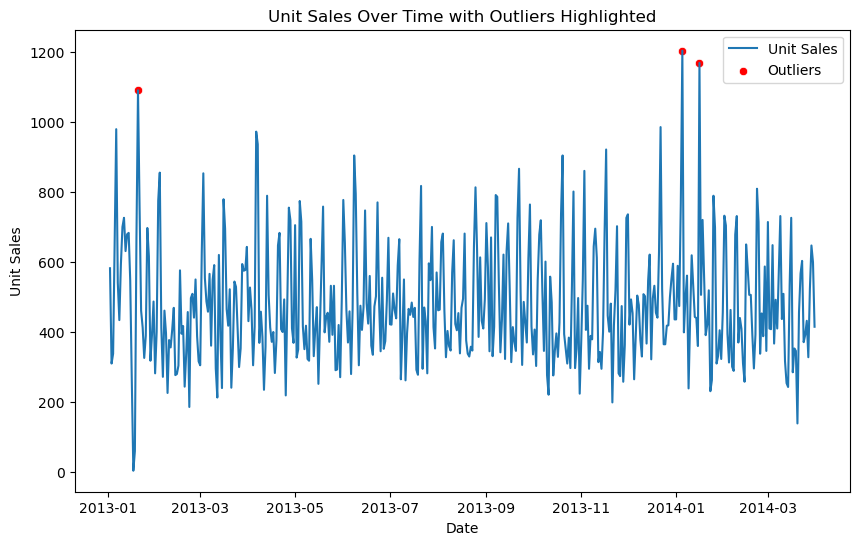

In [78]:
# plotting outliers
plt.figure(figsize=(10, 6))
sns.lineplot(data=timeseries_df, x=timeseries_df.index, y='unit_sales', label='Unit Sales')
sns.scatterplot(data=outliers, x=outliers.index, y='unit_sales', color='red', label='Outliers')
plt.title('Unit Sales Over Time with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

> Keep the outliers in mind. Maybe they are explained through hoildays.

## Feature Engineering

Turning data into usefull signals.

### year, month, day, day_of_week Signal

In [79]:
# create temporary date columns for feature engineering
timeseries_df['dates'] = timeseries_df.index

# Split the timestamp into model-friendly parts
timeseries_df['year'] = timeseries_df['dates'].dt.year
timeseries_df['month'] = timeseries_df['dates'].dt.month
timeseries_df['day'] = timeseries_df['dates'].dt.day
timeseries_df['day_of_week'] = timeseries_df['dates'].dt.dayofweek # Monday=0 … Sunday=6

# drope the temporary 'dates' column and unit_sales_z column as we won't need it for modeling
timeseries_df = timeseries_df.drop(columns=['dates', 'unit_sales_z'])

# Lets check the result
timeseries_df.head()

,unit_sales,year,month,day,day_of_week
2013-01-02,582.0,2013,1,2,2
2013-01-03,310.0,2013,1,3,3
2013-01-04,338.0,2013,1,4,4
2013-01-05,654.0,2013,1,5,5
2013-01-06,979.0,2013,1,6,6


### Holiday Signal

In [80]:
# create a holiday signal for store_nbr 44
holidays_signal = holidays_store_44_df['date'].copy()
holidays_signal = pd.to_datetime(holidays_signal)

# add a binary column to timeseries_df indicating whether each date is a holiday for store_nbr 44
timeseries_df['is_holiday'] = timeseries_df.index.isin(holidays_signal).astype(int)

# Lets check the result
timeseries_df.head()

,unit_sales,year,month,day,day_of_week,is_holiday
2013-01-02,582.0,2013,1,2,2,0
2013-01-03,310.0,2013,1,3,3,0
2013-01-04,338.0,2013,1,4,4,0
2013-01-05,654.0,2013,1,5,5,1
2013-01-06,979.0,2013,1,6,6,0


### Oil Price Signal

In [81]:
oil_df.head()
# join dcoilwtico from oil_df to timeseries_df based on the date index
timeseries_df = timeseries_df.merge(oil_df['dcoilwtico'], left_index=True, right_index=True, how='left')

# check for remaining missing values after merging
print(f"Na values in timeseries_df after merging with oil_df: \n{timeseries_df.isna().sum()}")

# Lets check the result
timeseries_df.head()

Na values in timeseries_df after merging with oil_df: 
unit_sales     0
year           0
month          0
day            0
day_of_week    0
is_holiday     0
dcoilwtico     0
dtype: int64


,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico
2013-01-02,582.0,2013,1,2,2,0,93.14
2013-01-03,310.0,2013,1,3,3,0,92.97
2013-01-04,338.0,2013,1,4,4,0,93.12
2013-01-05,654.0,2013,1,5,5,1,93.12
2013-01-06,979.0,2013,1,6,6,0,93.12


### Payday Signal

>Wages in the public sector are paid every two weeks on the **15** th and on the **last day of the month**. Supermarket sales could be affected by this.

In [84]:
# create Signal for end of month or 15th of the month
timeseries_df['is_payday'] = ((timeseries_df['day'] == 15) | (timeseries_df['day'] > timeseries_df['day'].shift(-1))).astype(int)

# Lets check the result
timeseries_df.head(31)

,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday
2013-01-02,582.0,2013,1,2,2,0,93.14,0
2013-01-03,310.0,2013,1,3,3,0,92.97,0
2013-01-04,338.0,2013,1,4,4,0,93.12,0
2013-01-05,654.0,2013,1,5,5,1,93.12,0
2013-01-06,979.0,2013,1,6,6,0,93.12,0
2013-01-07,541.0,2013,1,7,0,0,93.20,0
2013-01-08,434.0,2013,1,8,1,0,93.21,0
2013-01-09,593.0,2013,1,9,2,0,93.08,0
2013-01-10,700.0,2013,1,10,3,0,93.81,0
2013-01-11,726.0,2013,1,11,4,0,93.60,0


### Earthquake Signal

>A magnitude 7.8 **earthquake** struck Ecuador on **April 16, 2016**. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

In [85]:
# earthquake signal
timeseries_df['is_earthquake'] = ((timeseries_df.index >= '2016-04-16') & (timeseries_df.index <= '2016-04-16')).astype(int)

# Lets check the result
timeseries_df[timeseries_df['is_earthquake'] == 1]

,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake


**Is outside of timeseries date range**

## Visualizing Time Series Data

Discovering Trends, Seasonality and Residuals.